In [ ]:
!pip install odfpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 14.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for odfpy: filename=odfpy-1.4.1-py2.py3-none-any.whl size=160673 sha256=53131a308713d0ce8f3a717e07ec9a1fd1ea3dbe69ccf2a5e7a2d56bbdaa0221
  Stored in directory: /root/.cache/pip/wheels/36/5d/63/8243a7ee78fff0f944d638fd0e66d7278888f5e2285d7346b6
Successfully built odfpy


MAE (erro médio absoluto): 144.64


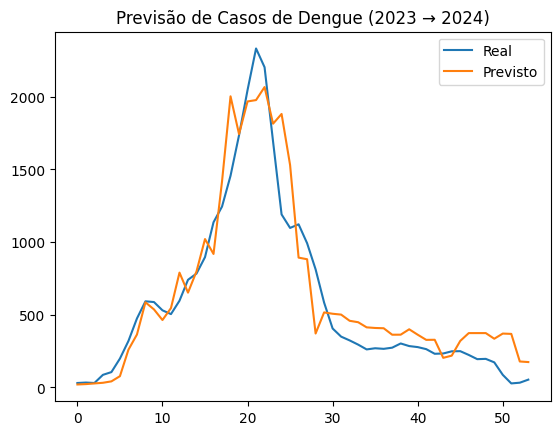

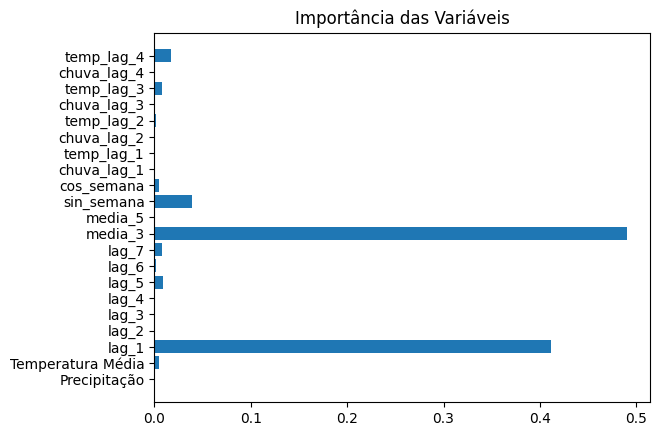

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

dengue_2023 = pd.read_csv("Casos_Bauru_2023.csv", sep='\t')
dengue_2024 = pd.read_csv("Dados_Bauru_2024.csv", sep=',')

clima_2023 = pd.read_csv("Bauru_dadosmeteorologicos_2023.csv")
clima_2024 = pd.read_csv("Bauru_dadosmeteorologicos_2024.csv")

dengue_2023.columns = ['notificados', 'ajustado', 'ativos']
dengue_2024.columns = ['notificados', 'ajustado', 'ativos']

dengue_2023['semana'] = np.arange(1, len(dengue_2023) + 1)
dengue_2024['semana'] = np.arange(len(dengue_2023)+1, len(dengue_2023)+len(dengue_2024)+1)

dengue = pd.concat([dengue_2023, dengue_2024])
dengue = dengue[['semana', 'ativos']]

clima = pd.concat([clima_2023, clima_2024])

clima['Data'] = pd.to_datetime(clima['Data'])
clima = clima.sort_values('Data')

for col in ['Precipitação', 'Temperatura Média']:
    clima[col] = (
        clima[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
    )
    clima[col] = pd.to_numeric(clima[col], errors='coerce')

clima = clima.dropna()

clima['semana'] = np.arange(1, len(clima) + 1)

clima_semanal = clima.groupby('semana').agg({
    'Precipitação': 'sum',
    'Temperatura Média': 'mean'
}).reset_index()

df = pd.merge(dengue, clima_semanal, on='semana')

for i in range(1, 8):
    df[f'lag_{i}'] = df['ativos'].shift(i)

df['media_3'] = df['ativos'].rolling(3).mean()
df['media_5'] = df['ativos'].rolling(5).mean()

df['sin_semana'] = np.sin(2 * np.pi * df['semana'] / 52)
df['cos_semana'] = np.cos(2 * np.pi * df['semana'] / 52)

for i in range(1, 5):
    df[f'chuva_lag_{i}'] = df['Precipitação'].shift(i)
    df[f'temp_lag_{i}'] = df['Temperatura Média'].shift(i)

df = df.dropna()

features = [col for col in df.columns if col not in ['ativos', 'semana']]

X = df[features]
y = df['ativos']

split = len(dengue_2023) - 10

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print(f"MAE (erro médio absoluto): {mae:.2f}")

plt.figure()
plt.plot(y_test.values, label='Real')
plt.plot(y_pred, label='Previsto')
plt.legend()
plt.title("Previsão de Casos de Dengue (2023 → 2024)")
plt.show()

importances = model.feature_importances_

plt.figure()
plt.barh(features, importances)
plt.title("Importância das Variáveis")
plt.show()


=== PRCC (Análise de Sensibilidade) ===
             Variável      PRCC
9             media_3  0.473231
3               lag_2 -0.325327
6               lag_5  0.178214
11         sin_semana  0.163777
12         cos_semana -0.160406
0        Precipitação  0.137683
7               lag_6 -0.135433
1   Temperatura Média  0.125374
13        chuva_lag_1 -0.115639
5               lag_4 -0.113752
16         temp_lag_2  0.111171
19        chuva_lag_4  0.104061
10            media_5  0.077879
17        chuva_lag_3  0.075146
8               lag_7 -0.056780
18         temp_lag_3 -0.046625
14         temp_lag_1  0.030062
15        chuva_lag_2 -0.011924
4               lag_3 -0.011809
2               lag_1 -0.002746
20         temp_lag_4  0.000204


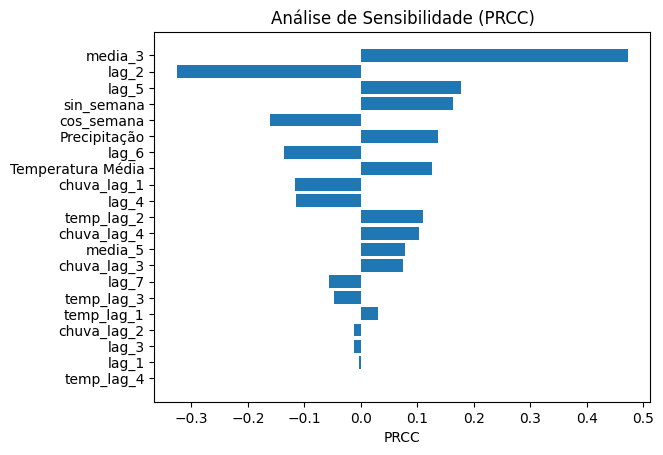

In [ ]:
from scipy.stats import rankdata, pearsonr

X_prcc = df[features].copy()
y_prcc = df['ativos'].copy()

X_ranked = X_prcc.apply(rankdata)
y_ranked = rankdata(y_prcc)

def compute_prcc(X, y):
    prcc_values = {}

    for col in X.columns:
        X_other = X.drop(columns=[col])

        beta_x = np.linalg.lstsq(X_other, X[col], rcond=None)[0]
        res_x = X[col] - X_other @ beta_x

        beta_y = np.linalg.lstsq(X_other, y, rcond=None)[0]
        res_y = y - X_other @ beta_y

        corr, _ = pearsonr(res_x, res_y)
        prcc_values[col] = corr

    return prcc_values

prcc_results = compute_prcc(X_ranked, y_ranked)

prcc_df = pd.DataFrame({
    'Variável': list(prcc_results.keys()),
    'PRCC': list(prcc_results.values())
})

prcc_df = prcc_df.sort_values(by='PRCC', key=abs, ascending=False)

print("\n=== PRCC (Análise de Sensibilidade) ===")
print(prcc_df)

plt.figure()
plt.barh(prcc_df['Variável'], prcc_df['PRCC'])
plt.title("Análise de Sensibilidade (PRCC)")
plt.xlabel("PRCC")
plt.gca().invert_yaxis()
plt.show()